In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import jax
jax.config.update('jax_platform_name', 'cpu')
from spectraformer.input_pipeline import preprocess_dataset, batch_sampler
import spectraformer.baselines
from spectraformer.model import SpectraFormer
import xarray as xr
import flax.linen as nn
import optax

### Dataset loading

In [7]:
train_ds = preprocess_dataset(xr.load_dataarray('data/SiC_19x10x3.nc'))
test_ds = preprocess_dataset(xr.load_dataarray('data/SiC+Graphene_50x20.nc'))

dummy_example = next(batch_sampler(train_ds, batch_size=1))
print("Data batch shapes:")
for k, v in dummy_example.items():
    print(f"  {k} -> {v.shape}")

Data batch shapes:
  spectra -> (1, 1015, 1)
  masked_spectra -> (1, 1015, 1)
  wave_number -> (1015, 1)
  mask -> (1015,)


### Model loading

In [8]:
from spectraformer.inference import predict, plot_results
import orbax.checkpoint as ocp
checkpointer = ocp.StandardCheckpointer()
ckpt_dir = "gs://spectraformer/checkpoints/"
test_batch = next(batch_sampler(test_ds, batch_size=1))

In [10]:
median_baseline_variables = checkpointer.restore(ckpt_dir + 'baselines:median/100x10/')
baseline_predictions = predict(spectraformer.baselines.median, median_baseline_variables, test_batch)
for k, v in baseline_predictions.items():
    print(f"  {k} -> {v.shape}")

I0000 00:00:1709638753.612633  398347 gcs_resource.cc:99] Using default AdmissionQueue with limit 32
I0000 00:00:1709638753.613741  399727 google_auth_provider.cc:147] Using credentials at /home/novelli/.config/gcloud/application_default_credentials.json
I0000 00:00:1709638753.613841  399727 google_auth_provider.cc:154] Using OAuth2 AuthProvider


  spectra -> (1015,)
  masked_spectra -> (1015,)
  wave_number -> (1015,)
  mask -> (1015,)
  predicted_spectra -> (1015,)
  predicted_difference -> (1015,)


Text(0.5, 1.0, 'Median Baseline')

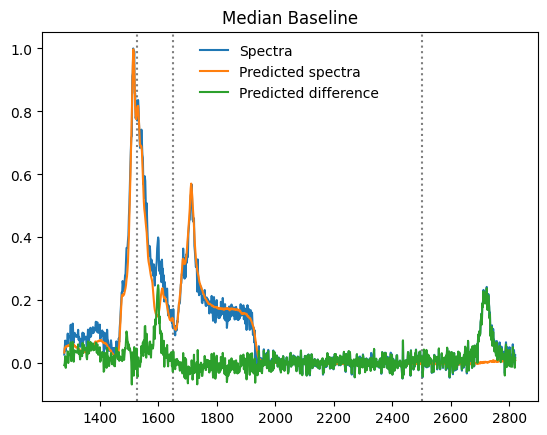

In [12]:
fig, ax = plot_results(baseline_predictions)
ax.set_title('Median Baseline')

In [18]:
model_tag = 'spectraformer:mid:poisson'
ckpt_manager = ocp.CheckpointManager(
        ckpt_dir + model_tag,
        item_handlers=ocp.StandardCheckpointHandler(),
    )

In [14]:
import ml_confs
from flax.training.train_state import TrainState

configs = ml_confs.from_dict(ckpt_manager.metadata())

# Re-initialize model based on loaded configs
model = SpectraFormer(
    num_heads=configs.num_heads,
    num_layers=configs.num_layers,
    embedding_dim=configs.embedding_dim,
)

# RNG Keys
root_key = jax.random.key(seed=configs.root_rng_seed)
main_key, params_key, dropout_key = jax.random.split(key=root_key, num=3)

# Model Initialization
variables = model.init(
    params_key,
    dummy_example["masked_spectra"][0],
    dummy_example["wave_number"],
    dummy_example["mask"],
    training=False,
)

state = TrainState.create(
    apply_fn=jax.jit(
        model.apply, static_argnames=("training", "capture_intermediates")
    ),
    params=variables["params"],
    tx=optax.adam(configs.learning_rate),
)
# Restore checkpoint
state = ckpt_manager.restore(
    ckpt_manager.latest_step(), args=ocp.args.StandardRestore(state)
)

In [15]:
tabulate_fn = nn.tabulate(model, jax.random.key(0), depth = 1, console_kwargs={'force_jupyter': True})
print(tabulate_fn(dummy_example['masked_spectra'][0], dummy_example['wave_number'], dummy_example['mask'], training = False))

                                               SpectraFormer Summary                                               
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path                 ┃ module                ┃ inputs               ┃ outputs           ┃ params                ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│                      │ SpectraFormer         │ - float32[1015,1]    │ float32[1015,1]   │                       │
│                      │                       │ - float32[1015,1]    │                   │                       │
│                      │                       │ - bool[1015]         │                   │                       │
│                      │                       │ - training: False    │                   │                       │
├──────────────────────┼───────────────────────┼──────────────────────┼───────────────────┼───────────────────────┤
│ LinearProjection_0   │ LinearProjection      │ float32[1015,1]      │ float32[1015,128] │ 256 (1.0 KB)          │
├──────────────────────┼───────────────────────┼──────────────────────┼───────────────────┼───────────────────────┤
│ LinearProjection_1   │ LinearProjection      │ float32[1015,1]      │ float32[1015,128] │ 256 (1.0 KB)          │
├──────────────────────┼───────────────────────┼──────────────────────┼───────────────────┼───────────────────────┤
│ TransformerEncoderL… │ TransformerEncoderLa… │ - float32[1015,128]  │ float32[1015,128] │ 231,296 (925.2 KB)    │
│                      │                       │ -                    │                   │                       │
│                      │                       │ float32[1,1015,1015] │                   │                       │
│                      │                       │ - training: False    │                   │                       │
├──────────────────────┼───────────────────────┼──────────────────────┼───────────────────┼───────────────────────┤
│ TransformerEncoderL… │ TransformerEncoderLa… │ - float32[1015,128]  │ float32[1015,128] │ 231,296 (925.2 KB)    │
│                      │                       │ -                    │                   │                       │
│                      │                       │ float32[1,1015,1015] │                   │                       │
│                      │                       │ - training: False    │                   │                       │
├──────────────────────┼───────────────────────┼──────────────────────┼───────────────────┼───────────────────────┤
│ TransformerEncoderL… │ TransformerEncoderLa… │ - float32[1015,128]  │ float32[1015,128] │ 231,296 (925.2 KB)    │
│                      │                       │ -                    │                   │                       │
│                      │                       │ float32[1,1015,1015] │                   │                       │
│                      │                       │ - training: False    │                   │                       │
├──────────────────────┼───────────────────────┼──────────────────────┼───────────────────┼───────────────────────┤
│ TransformerEncoderL… │ TransformerEncoderLa… │ - float32[1015,128]  │ float32[1015,128] │ 231,296 (925.2 KB)    │
│                      │                       │ -                    │                   │                       │
│                      │                       │ float32[1,1015,1015] │                   │                       │
│                      │                       │ - training: False    │                   │                       │
├──────────────────────┼───────────────────────┼──────────────────────┼───────────────────┼───────────────────────┤
│ LayerNorm_0          │ LayerNorm             │ float32[1015,128]    │ float32[1015,128] │ bias: float32[128]    │
│                      │                       │        

In [16]:
spectraformer_predictions = predict(state.apply_fn, {'params': state.params}, test_batch, test_batch['mask'])
for k, v in spectraformer_predictions.items():
    print(f"  {k} -> {v.shape}")

  spectra -> (1015,)
  masked_spectra -> (1015,)
  wave_number -> (1015,)
  mask -> (1015,)
  predicted_spectra -> (1015,)
  predicted_difference -> (1015,)


Text(0.5, 1.0, 'Spectraformer spectraformer:mid:poisson')

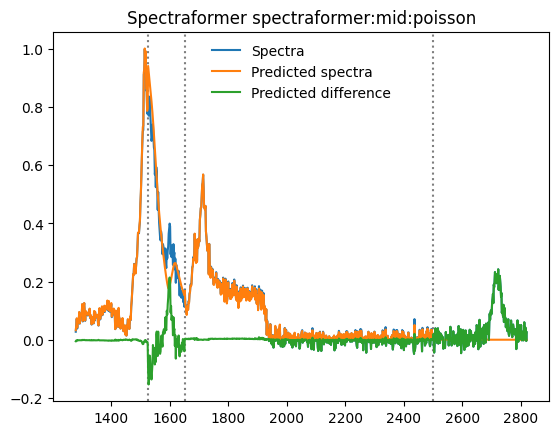

In [19]:
fig, ax = plot_results(spectraformer_predictions)
ax.set_title(f'Spectraformer {model_tag}')